In [2]:
import pandas as pd

df = pd.read_csv("Garmin Running Dataset.csv")

df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 509 entries, 0 to 508
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Activity Type             509 non-null    object 
 1   Date                      509 non-null    object 
 2   Favorite                  509 non-null    bool   
 3   Title                     509 non-null    object 
 4   Distance                  509 non-null    float64
 5   Calories                  509 non-null    object 
 6   Time                      509 non-null    object 
 7   Avg HR                    509 non-null    object 
 8   Max HR                    509 non-null    object 
 9   Aerobic TE                509 non-null    object 
 10  Avg Run Cadence           509 non-null    object 
 11  Max Run Cadence           509 non-null    object 
 12  Avg Pace                  509 non-null    object 
 13  Best Pace                 509 non-null    object 
 14  Total Asce

,Distance,Training Stress Score®,Number of Laps
count,509.000000,509.0,509.000000
mean,7.271788,0.0,9.383104
std,2.413520,0.0,5.345963
min,0.110000,0.0,1.000000
25%,5.190000,0.0,6.000000
50%,7.030000,0.0,8.000000
75%,9.000000,0.0,12.000000
max,20.910000,0.0,39.000000


In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Missing varsa
df = df.dropna()
print(df)

         Activity Type                Date  Favorite              Title  \
508            Running 2020-07-18 06:43:49     False      Kuşadası Koşu   
507            Running 2020-07-20 06:27:02     False      Kuşadası Koşu   
506            Running 2020-07-21 06:36:02     False      Kuşadası Koşu   
505            Running 2020-07-24 06:42:05     False      Kuşadası Koşu   
504            Running 2020-07-27 06:16:10     False      Kuşadası Koşu   
..                 ...                 ...       ...                ...   
4    Treadmill Running 2026-02-12 16:43:56     False  Treadmill Running   
3    Treadmill Running 2026-02-14 15:25:14     False  Treadmill Running   
2              Running 2026-02-19 16:52:23     False      Tuzla Running   
1    Treadmill Running 2026-03-08 17:14:19     False  Treadmill Running   
0              Running 2026-03-14 16:29:29     False      Tuzla Running   

     Distance Calories      Time Avg HR Max HR Aerobic TE  ...  \
508      2.46      341  00:29:27 

In [10]:


df = pd.read_csv("Garmin Running Dataset.csv")

df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

df['days_since_last_run'] = df['Date'].diff().dt.days
df['break_flag'] = df['days_since_last_run'] > 7

df['week'] = df['Date'].dt.isocalendar().week
weekly_freq = df.groupby('week').size()
df['weekly_frequency'] = df['week'].map(weekly_freq)

def pace_to_min(pace_str):
    if pd.isna(pace_str):
        return None
    mins, secs = str(pace_str).split(':')
    return int(mins) + int(secs) / 60

df['pace_min'] = df['Avg Pace'].apply(pace_to_min)

df['rolling_pace'] = df['pace_min'].rolling(5).mean()

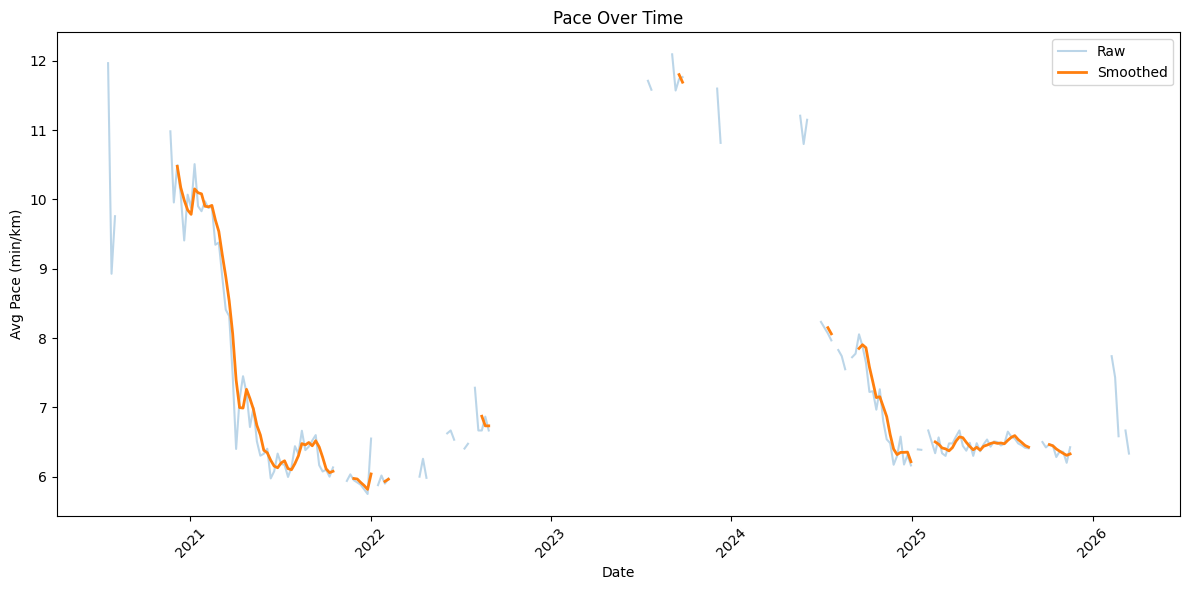

In [22]:
# TIME SERIES

import pandas as pd
import matplotlib.pyplot as plt

# 1. Date kolonunu düzelt
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# 2. Avg Pace'i mm:ss -> dakika(float) çevir
pace_split = df['Avg Pace'].str.split(':', expand=True)
df['Avg Pace Min'] = pace_split[0].astype(int) + pace_split[1].astype(int) / 60

# 3. Haftalık ortalama al
df_weekly = df.set_index('Date')['Avg Pace Min'].resample('W').mean()

# 4. Smooth
df_smooth = df_weekly.rolling(3).mean()

# 5. Plot
plt.figure(figsize=(12, 6))
plt.plot(df_weekly.index, df_weekly, alpha=0.3, label='Raw')
plt.plot(df_smooth.index, df_smooth, linewidth=2, label='Smoothed')

plt.title('Pace Over Time')
plt.xlabel('Date')
plt.ylabel('Avg Pace (min/km)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

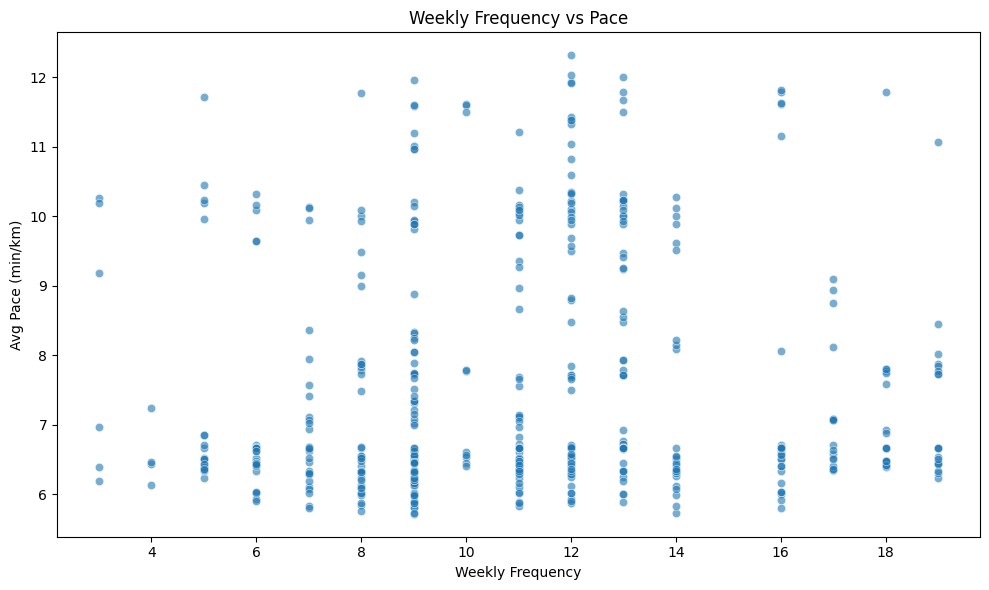

In [27]:
# TRAINING FREQUENCY AND PERFORMANCE

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Avg Pace'i numeric'e çevir (KRİTİK)
pace_split = df['Avg Pace'].str.split(':', expand=True)
df['Avg Pace Min'] = pace_split[0].astype(int) + pace_split[1].astype(int) / 60

# 2. Plot
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='weekly_frequency',
    y='Avg Pace Min',
    data=df,
    alpha=0.6
)

plt.title("Weekly Frequency vs Pace")
plt.xlabel("Weekly Frequency")
plt.ylabel("Avg Pace (min/km)")

plt.tight_layout()
plt.show()

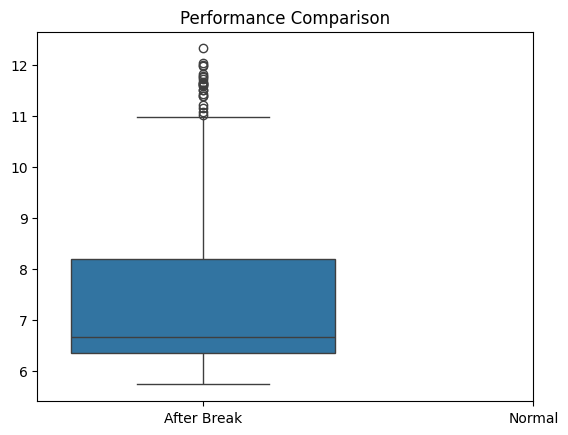

In [30]:
# BREAK ANALYSIS

before_break = df[df['break_flag'] == True]['pace_min']
normal = df[df['break_flag'] == False]['pace_min']

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=[before_break, normal])
plt.xticks([0,1], ['After Break', 'Normal'])
plt.title("Performance Comparison")
plt.show()

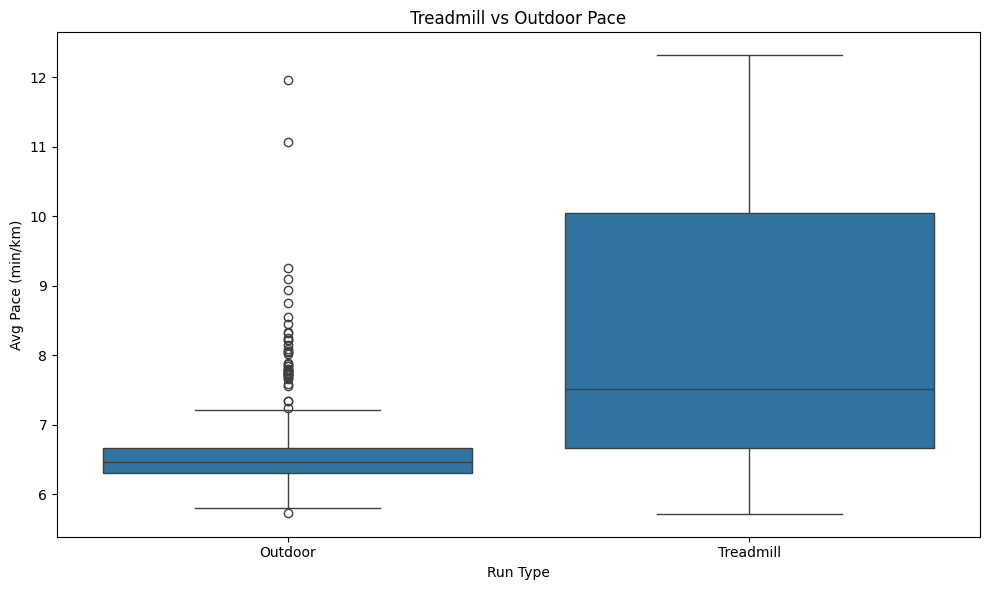

In [36]:
# ENVIRONMENT

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Pace'i çevir
pace_split = df['Avg Pace'].str.split(':', expand=True)
df['Avg Pace Min'] = pace_split[0].astype(int) + pace_split[1].astype(int) / 60

# Yeni kategori oluştur (daha temiz)
df['Run Type'] = df['Activity Type'].apply(
    lambda x: 'Treadmill' if x == 'Treadmill Running' else 'Outdoor'
)

# Plot
plt.figure(figsize=(10,6))

sns.boxplot(
    x='Run Type',
    y='Avg Pace Min',
    data=df
)

plt.title("Treadmill vs Outdoor Pace")
plt.ylabel("Avg Pace (min/km)")
plt.tight_layout()

plt.show()

In [ ]:
# HYPOTHESIS TESTING

In [39]:
# TRAINING FREQUENCY AND PERFORMANCE

import pandas as pd
from scipy.stats import pearsonr

# Avg Pace: mm:ss -> dakika (float)
pace_split = df['Avg Pace'].str.split(':', expand=True)
df['Avg Pace Min'] = pace_split[0].astype(int) + pace_split[1].astype(int) / 60

# Gerekli kolonları temizle
corr_df = df[['weekly_frequency', 'Avg Pace Min']].dropna()

# Pearson correlation
corr, p = pearsonr(corr_df['weekly_frequency'], corr_df['Avg Pace Min'])

print("Correlation:", corr)
print("P-value:", p)

Correlation: 0.04308972638289931
P-value: 0.33194227135075854


In [46]:
# BREAK LENGTH AND RECOVERY

from scipy.stats import ttest_ind

t, p = ttest_ind(before_break, normal)
print("p-value: ",p)

p-value:  0.0812514047841055


In [47]:
# TREADMILL VS OUTDOOR

df['Environment'] = df['Activity Type'].apply(
    lambda x: 'Treadmill' if x == 'Treadmill Running' else 'Outdoor'
)

pace_split = df['Avg Pace'].str.split(':', expand=True)
df['Avg Pace Min'] = pace_split[0].astype(int) + pace_split[1].astype(int) / 60

from scipy.stats import ttest_ind

t, p = ttest_ind(
    df[df['Environment'] == 'Treadmill']['Avg Pace Min'],
    df[df['Environment'] == 'Outdoor']['Avg Pace Min']
)

print("t-stat:", t)
print("p-value:", p)



t-stat: 11.350568785842919
p-value: 9.20904459706569e-27


Number of runs after break: 39
Normal run number: 470
Average pace after break: 7.978
Average pace of normal runs: 7.485


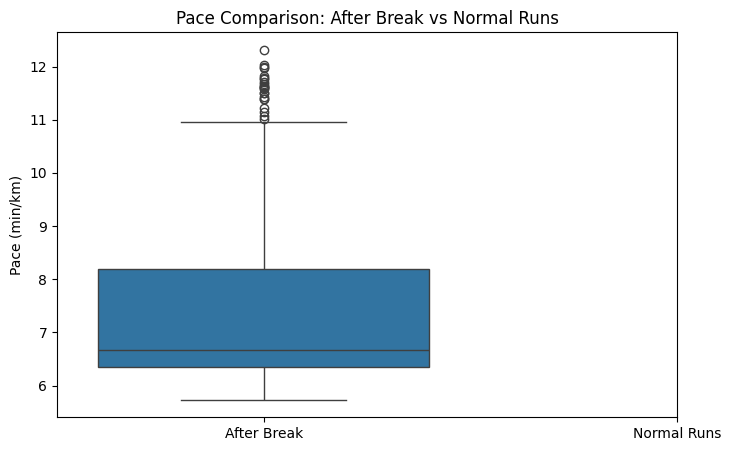

T-statistic: 1.3711
P-value: 0.1777
Conclusion: There is not any meaningful statistical difference between normal runs and runs after break.
Interpretation: After the break average pace is higher so, performance decreased.


In [53]:



df.columns = df.columns.str.strip()


df['Date'] = pd.to_datetime(df['Date'])

# Sort in terms of dates
df = df.sort_values('Date').reset_index(drop=True)

# Pace'i mm:ss
def pace_to_min(pace_str):
    if pd.isna(pace_str):
        return None
    pace_str = str(pace_str).strip()
    mins, secs = pace_str.split(':')
    return int(mins) + int(secs) / 60

df['pace_min'] = df['Avg Pace'].apply(pace_to_min)

# How many days since the last run
df['days_since_last_run'] = df['Date'].diff().dt.days

# If the break is longer than 7 days
df['break_flag'] = df['days_since_last_run'] > 7

after_break = df.loc[df['break_flag'] == True, 'pace_min'].dropna()
normal_runs = df.loc[df['break_flag'] == False, 'pace_min'].dropna()


print("Number of runs after break:", len(after_break))
print("Normal run number:", len(normal_runs))

# Average paces
print("Average pace after break:", round(after_break.mean(), 3))
print("Average pace of normal runs:", round(normal_runs.mean(), 3))

# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(data=[after_break, normal_runs])
plt.xticks([0, 1], ['After Break', 'Normal Runs'])
plt.ylabel('Pace (min/km)')
plt.title('Pace Comparison: After Break vs Normal Runs')
plt.show()

# Hypothesis Testing
t_stat, p_value = ttest_ind(after_break, normal_runs, equal_var=False)

print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 4))


if p_value < 0.05:
    print("Conclusion: There is a meaningful statistical difference between normal runs and runs after the break.")
else:
    print("Conclusion: There is not any meaningful statistical difference between normal runs and runs after break.")

if after_break.mean() > normal_runs.mean():
    print("Interpretation: After the break average pace is higher so, performance decreased.")
else:
    print("Interpretation: After the break average pace is lower so, performance increased.")